# Run TCLab Experiments

Alex Dowling, University of Notre Dame

## Setup

In [1]:
# Install Pyomo and solvers for Google Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/IDAES/idaes-pse/main/scripts/colab_helper.py"
    import colab_helper

    colab_helper.install_idaes()
    colab_helper.install_ipopt()

# Set plotting defaults
import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('lines', linewidth=3)

## Load Control Signal

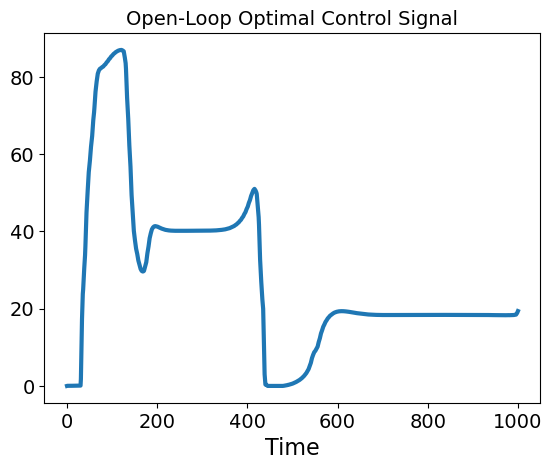

In [2]:
import pandas as pd

# input_data = pd.read_csv('./data/u_via_GP_of_resid_with_du_penalty.csv')
# input_data = pd.read_csv('./data/solution_benchmark_0o5du1.csv')
input_data = pd.read_csv('./data/tclab_final_as_of_20240807__u_GP.csv')

input_data.head()

input_data.plot(x='Time', y='Q1', title='Open-Loop Optimal Control Signal', legend=False)
plt.show()

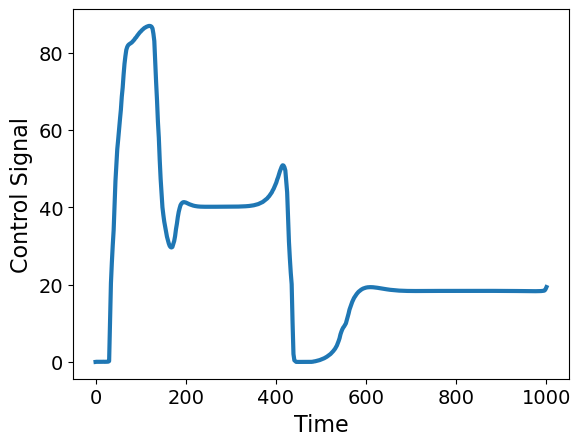

In [3]:
import numpy as np

def control_signal(t):
    return np.interp(t, input_data['Time'], input_data['Q1'])

t_plot = np.linspace(0, 1000, 500)

plt.plot(t_plot, control_signal(t_plot))
plt.xlabel('Time')
plt.ylabel('Control Signal')
plt.show()

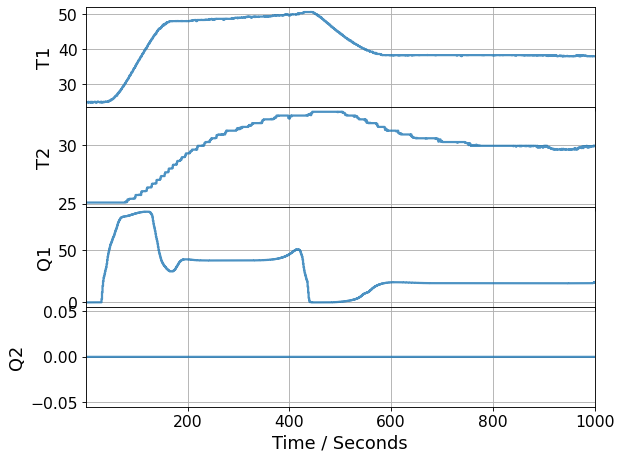

TCLab disconnected successfully.


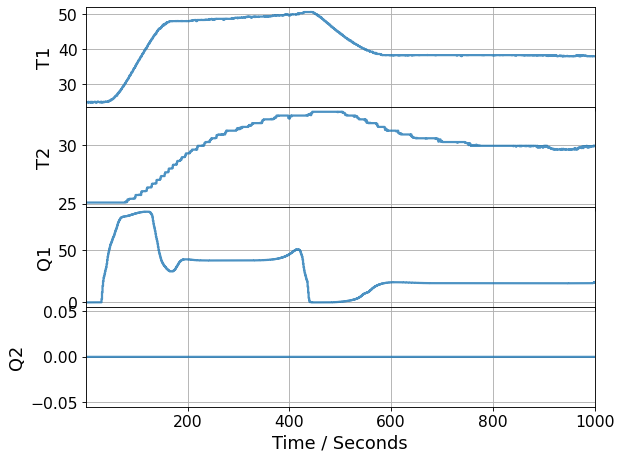

In [4]:
from tclab import TCLab, clock, Historian, Plotter

# experimental parameters
P1 = 200
tfinal = 1000

# perform experiment
with TCLab() as lab:
    lab.P1 = P1
    h = Historian(lab.sources)
    p = Plotter(h, tfinal)
    lab.Q1(control_signal(0))
    for t in clock(tfinal):
        lab.Q1(control_signal(t))
        p.update(t)

In [5]:
data_file = 'data/validation_experiment6.csv'
h.to_csv(data_file)

In [6]:
tvec = [0, 50, 150, 450, 550, 1000]

def r(t):  # setpoint/reference
    return np.interp(t, tvec, [0, 0, 25, 25, 10, 10])

In [7]:
df2 = pd.read_csv(data_file)

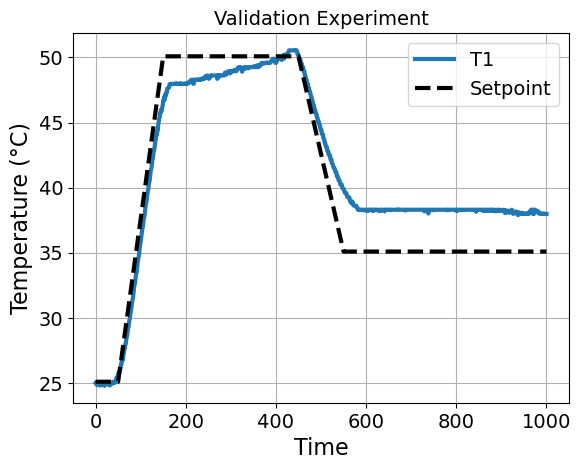

In [8]:
df2.plot(x='Time', y=['T1'], title='Validation Experiment')
#Tamb = df2['T1'][0]
Tamb = df2['T2'][0] # taking from the second channel in case the first one has not fully cooled down yet
plt.plot(df2['Time'], r(df2['Time']) + Tamb, 'k--', label='Setpoint')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid()
plt.show()